In [1]:
import pandas as pd

print(pd.__version__)

df = pd.read_csv("C:/intern/battery_dataset.csv")
df


3.0.3


,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351


In [2]:
import seaborn as sns

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BatteryID           2000 non-null   str    
 1   BatchID             2000 non-null   str    
 2   Cycle               2000 non-null   int64  
 3   Voltage             2000 non-null   float64
 4   Current             2000 non-null   float64
 5   Temperature         2000 non-null   float64
 6   ChargeTime          2000 non-null   float64
 7   DischargeTime       2000 non-null   float64
 8   InternalResistance  2000 non-null   float64
 9   Capacity            2000 non-null   float64
 10  AmbientHumidity     2000 non-null   float64
 11  C_Rate              2000 non-null   float64
 12  SOH                 2000 non-null   float64
dtypes: float64(10), int64(1), str(2)
memory usage: 228.6 KB


In [4]:
df.isnull().sum()

BatteryID             0
BatchID               0
Cycle                 0
Voltage               0
Current               0
Temperature           0
ChargeTime            0
DischargeTime         0
InternalResistance    0
Capacity              0
AmbientHumidity       0
C_Rate                0
SOH                   0
dtype: int64

In [5]:
df.describe()

,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,3.592491,1.236696,25.281789,74.094272,75.210691,0.149986,1.999961,50.483573,1.264644,61.293052
std,577.494589,0.346469,0.428394,4.902033,25.482926,25.795982,0.057751,0.289359,11.328639,0.434534,18.481668
min,1.000000,3.000289,0.500046,9.902439,30.004754,30.021679,0.046516,1.460427,30.034148,0.500917,27.791377
25%,500.750000,3.291341,0.871196,21.952101,52.697757,52.858818,0.100005,1.752301,40.942929,0.901011,45.290571
50%,1000.500000,3.585221,1.223112,25.238242,73.803345,75.158765,0.149887,2.001169,50.940957,1.259172,61.085327
75%,1500.250000,3.893895,1.605997,28.464827,95.252876,97.675132,0.200170,2.252186,59.951592,1.639257,76.830696
max,2000.000000,4.199353,1.999337,40.965538,119.875559,119.970588,0.251932,2.521192,69.965983,1.999807,100.000000


In [6]:
df.duplicated().sum()

np.int64(0)

UNIVARIATE ANALYSIS


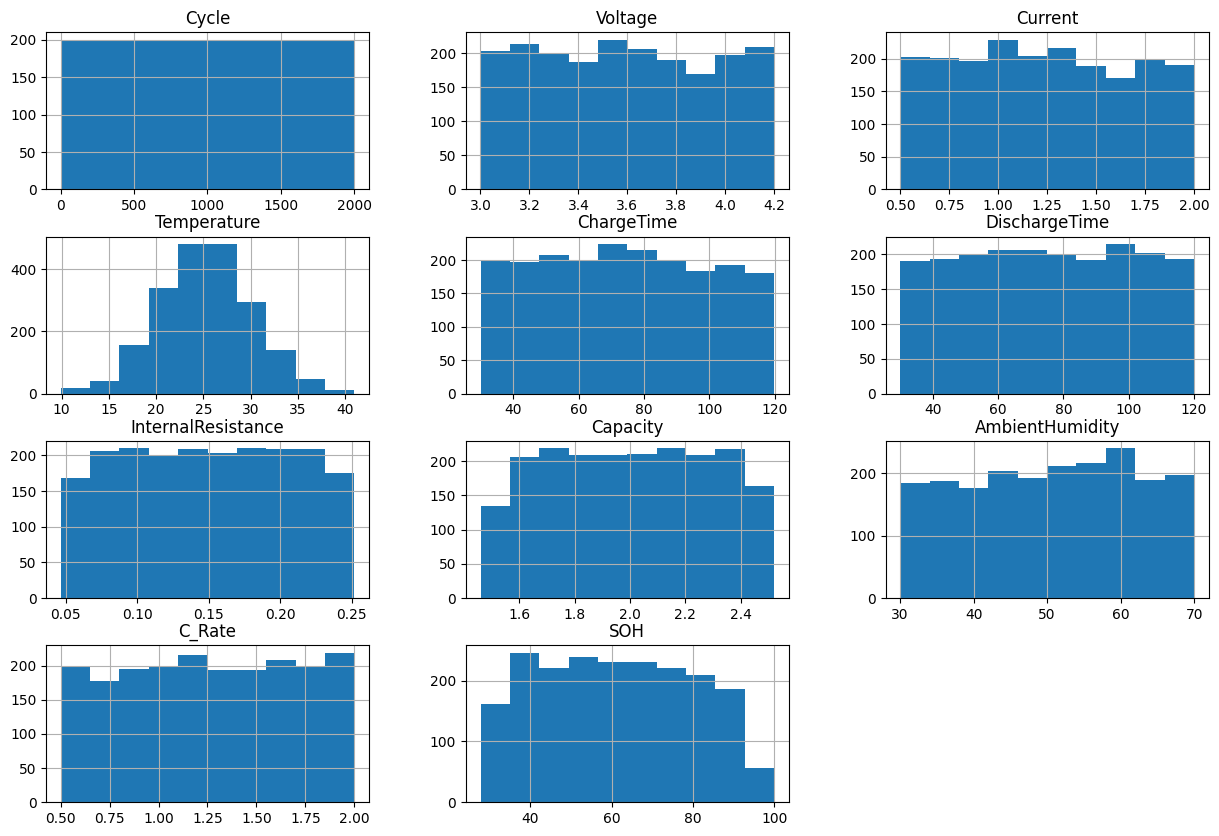

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns



df.hist(figsize=(15,10))
plt.show()

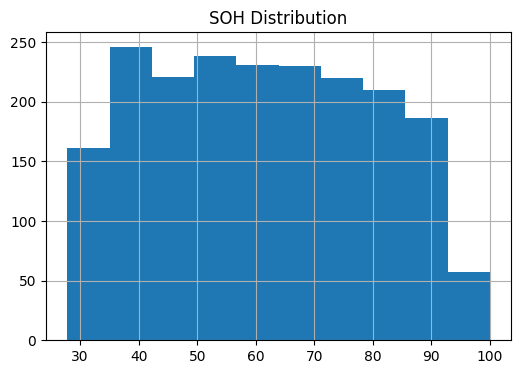

In [8]:
plt.figure(figsize=(6,4))
df['SOH'].hist()
plt.title('SOH Distribution')
plt.show()

In [9]:
df.shape

(2000, 13)

    OUTLIER DETECTION
    

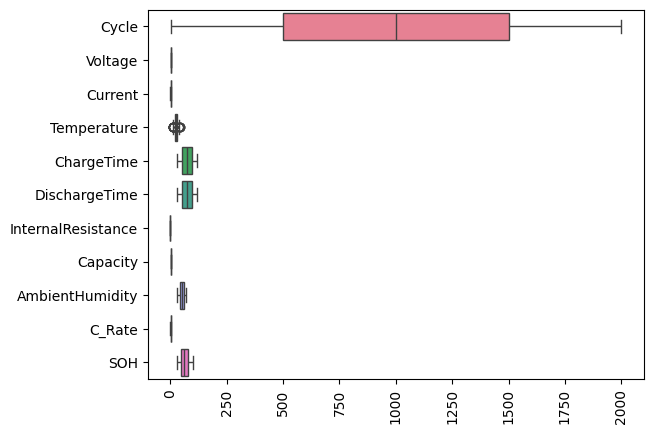

In [10]:
import seaborn as sns
plt.Figure(figsize=(10,15))
sns.boxplot(data = df,orient= "h")
plt.xticks (rotation = 90)
plt.show()

In [11]:
import pandas as pd

numerical_cols = df.select_dtypes(include='number').columns

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")





Cycle: 0 outliers
Voltage: 0 outliers
Current: 0 outliers
Temperature: 16 outliers
ChargeTime: 0 outliers
DischargeTime: 0 outliers
InternalResistance: 0 outliers
Capacity: 0 outliers
AmbientHumidity: 0 outliers
C_Rate: 0 outliers
SOH: 0 outliers


In [12]:
Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Temperature'] < lower) |
    (df['Temperature'] > upper)
]

print(outliers)

     BatteryID BatchID  Cycle   Voltage   Current  Temperature  ChargeTime  \
281    BAT0282  BatchD    282  4.183412  1.186893    10.757287   35.086412   
321    BAT0322  BatchA    322  4.151695  0.674538    10.518723   92.819142   
575    BAT0576  BatchB    576  3.214224  1.495737    12.044789   84.394265   
759    BAT0760  BatchC    760  3.542658  1.704518    10.638689   75.935345   
811    BAT0812  BatchC    812  3.774285  0.572544    10.393248   79.904020   
835    BAT0836  BatchD    836  3.698574  1.499783    40.965538   98.724943   
970    BAT0971  BatchD    971  3.241410  1.398949    11.483839   68.204355   
1177   BAT1178  BatchD   1178  3.654100  0.793569    40.688743   75.289729   
1191   BAT1192  BatchC   1192  3.090633  0.582099    10.298057   97.829952   
1244   BAT1245  BatchC   1245  3.515798  1.005996     9.902439  115.295952   
1255   BAT1256  BatchB   1256  4.049696  1.065300    38.798300   72.458068   
1478   BAT1479  BatchB   1479  3.289493  0.772726    11.978931  

In [13]:
df.shape

(2000, 13)

In [14]:
# Create a copy of original data
df_clean = df.copy()

# Select numerical columns
numerical_cols = df_clean.select_dtypes(include='number').columns

for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (2000, 13)
After Removing Outliers: (1984, 13)


CORRELATION ANALYSIS


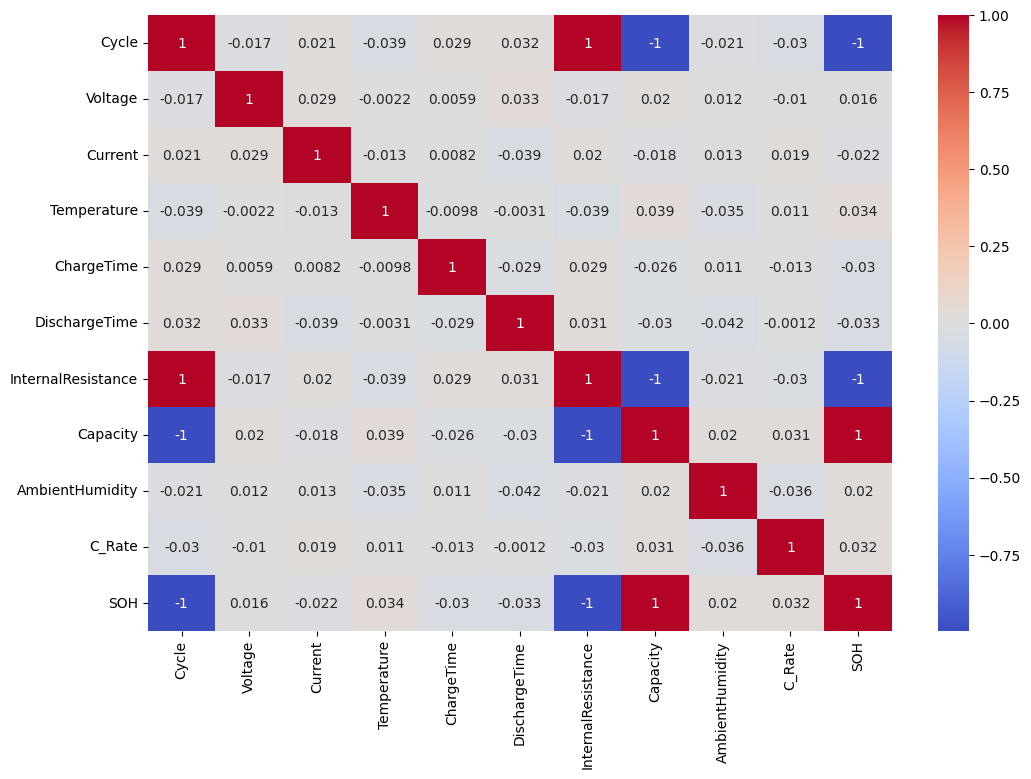

In [15]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

BATTERY PERFOTMANCE PREDICTION 

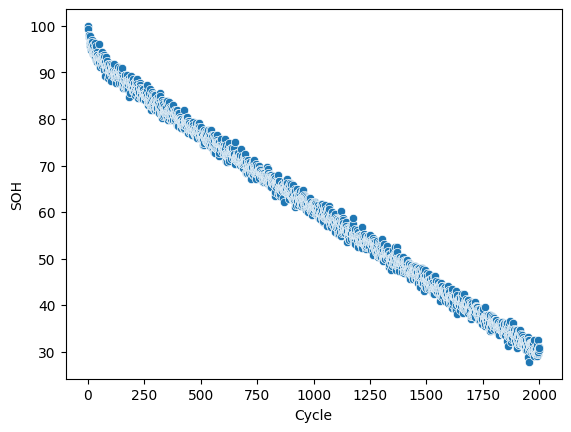

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Cycle', y='SOH', data=df_clean)
plt.show()

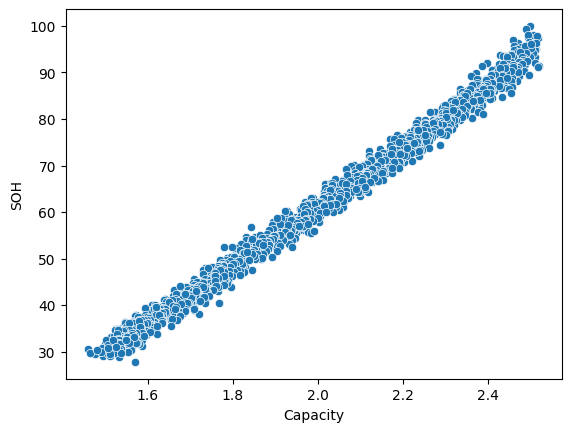

In [17]:
sns.scatterplot(x='Capacity', y='SOH', data=df_clean)
plt.show()

FEATURE ENGINNERING 


In [18]:
df_clean["Temp_stress"] = df_clean["Temperature"] * df_clean["Current"]
df_clean

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124


Shows how resistance changes with battery aging

In [19]:
df_clean['Resistance_Per_Cycle'] = (
    df_clean['InternalResistance'] / (df_clean['Cycle'] + 1)
)
df_clean

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress,Resistance_Per_Cycle
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068,0.026112
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662,0.016518
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324,0.012582
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335,0.010444
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611,0.008954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495,0.000124
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994,0.000125
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007,0.000124
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124,0.000124


CAPACITY LOSS

In [20]:
max_capacity = df_clean['Capacity'].max()
max_capacity



np.float64(2.521192285182002)

In [21]:
# DIFFERENCE

df_clean['Capacity_Loss'] = (
    max_capacity - df_clean['Capacity']
)

df_clean

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress,Resistance_Per_Cycle,Capacity_Loss
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068,0.026112,0.021035
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662,0.016518,0.029848
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324,0.012582,0.025022
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335,0.010444,0.013408
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611,0.008954,0.014882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495,0.000124,1.002821
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994,0.000125,1.030629
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007,0.000124,1.039949
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124,0.000124,0.995275


Voltage to Current Ratio

In [22]:
df_clean['Voltage_Current_Ratio'] = (
    df['Voltage'] / (df_clean['Current'] + 0.001)
)

df_clean

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress,Resistance_Per_Cycle,Capacity_Loss,Voltage_Current_Ratio
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068,0.026112,0.021035,3.978556
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662,0.016518,0.029848,1.860590
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324,0.012582,0.025022,3.867171
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335,0.010444,0.013408,4.161791
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611,0.008954,0.014882,3.761096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495,0.000124,1.002821,6.759783
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994,0.000125,1.030629,2.536890
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007,0.000124,1.039949,5.868598
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124,0.000124,0.995275,3.267021


Charge-Discharge Ratio

In [23]:
df_clean['Charge_Discharge_Ratio'] = (
    df_clean['ChargeTime'] /
    (df_clean['DischargeTime'] + 0.001)
)
df_clean


,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress,Resistance_Per_Cycle,Capacity_Loss,Voltage_Current_Ratio,Charge_Discharge_Ratio
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068,0.026112,0.021035,3.978556,1.015459
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662,0.016518,0.029848,1.860590,0.357294
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324,0.012582,0.025022,3.867171,0.801054
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335,0.010444,0.013408,4.161791,0.707550
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611,0.008954,0.014882,3.761096,1.561438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495,0.000124,1.002821,6.759783,0.728576
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994,0.000125,1.030629,2.536890,2.757586
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007,0.000124,1.039949,5.868598,0.365112
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124,0.000124,0.995275,3.267021,1.487545


In [24]:

df_clean['Cycle_Stress'] = (
    df_clean['Cycle'] * df_clean['Temperature']

)
df_clean

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH,Temp_stress,Resistance_Per_Cycle,Capacity_Loss,Voltage_Current_Ratio,Charge_Discharge_Ratio,Cycle_Stress
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000,23.754068,0.026112,0.021035,3.978556,1.015459,25.888505
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837,31.102662,0.016518,0.029848,1.860590,0.357294,36.646556
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097,26.615324,0.012582,0.025022,3.867171,0.801054,80.702968
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562,26.624335,0.010444,0.013408,4.161791,0.707550,112.211715
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179,23.594611,0.008954,0.014882,3.761096,1.561438,138.994761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BAT1996,BatchA,1996,3.735221,0.551565,23.575623,71.461648,98.082991,0.248514,1.518371,66.519416,1.967510,32.424118,13.003495,0.000124,1.002821,6.759783,0.728576,47056.942576
1996,BAT1997,BatchB,1997,3.702451,1.458445,23.719101,110.174172,39.952127,0.249314,1.490563,45.084683,1.156045,29.909219,34.592994,0.000125,1.030629,2.536890,2.757586,47367.045171
1997,BAT1998,BatchA,1998,3.657139,0.622171,23.792513,38.501618,105.450404,0.247121,1.481243,38.799208,1.207759,30.458467,14.803007,0.000124,1.039949,5.868598,0.365112,47537.440516
1998,BAT1999,BatchC,1999,3.768580,1.152522,24.691179,118.998814,79.995808,0.248197,1.525917,54.324047,1.247897,30.965351,28.457124,0.000124,0.995275,3.267021,1.487545,49357.666822


Correlation Check

In [25]:
corr = df_clean.corr(numeric_only=True)

print(
    corr['SOH']
    .sort_values(ascending=False)
)

SOH                       1.000000
Capacity                  0.995617
Resistance_Per_Cycle      0.274693
Temperature               0.034169
C_Rate                    0.031709
Voltage_Current_Ratio     0.022034
AmbientHumidity           0.020454
Voltage                   0.016328
Charge_Discharge_Ratio    0.001131
Temp_stress              -0.002295
Current                  -0.022298
ChargeTime               -0.030301
DischargeTime            -0.033178
Cycle_Stress             -0.936988
Capacity_Loss            -0.995617
InternalResistance       -0.997423
Cycle                    -0.998001
Name: SOH, dtype: float64


In [26]:
selected_features = [
    'Cycle',
    'InternalResistance',
    'Capacity',
    'Resistance_Per_Cycle',
    'Temperature',
    'Voltage'
]

In [27]:
y = df['SOH']

In [28]:
from sklearn.ensemble import RandomForestRegressor

X = df_clean[selected_features]
y = df_clean['SOH']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

                Feature  Importance
0                 Cycle    0.936233
1    InternalResistance    0.048318
3  Resistance_Per_Cycle    0.013995
2              Capacity    0.000511
5               Voltage    0.000479
4           Temperature    0.000463


In [29]:
X = df_clean[selected_features]
y = df_clean['SOH']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1587, 6)
(397, 6)


scale features

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[-0.70949754, -0.68767817,  0.62275081, -0.10958615, -0.22170144,
         0.73105009],
       [ 1.50707244,  1.52123355, -1.56342529, -0.16960088, -1.53886154,
         1.39987297],
       [ 0.11004549,  0.14221488, -0.08398967, -0.14795538, -0.27407709,
         1.03698209],
       ...,
       [ 0.02013782, -0.01801818, -0.07655008, -0.14947314, -0.84870874,
         1.3763967 ],
       [ 0.41953537,  0.42516886, -0.46289561, -0.15623479,  0.61689094,
         1.35218094],
       [-0.69912358, -0.69834495,  0.80431704, -0.11252036,  1.75370271,
        -1.31307993]], shape=(397, 6))

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.8688308516333899
RMSE: 1.101447907885375
R2: 0.9964548382748076


DECISION TREE REGRESSSION


In [33]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

RANDOMFOREST REGRESION

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Gradient Boosting

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

Evaluate All Models

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

CREATE COMPARISION TABLE 

In [37]:
results = []

models = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

for name, pred in models.items():

    mae, rmse, r2 = evaluate(
        y_test,
        pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

print(comparison)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.868831  1.101448  0.996455
1      Decision Tree  1.171716  1.478618  0.993611
2      Random Forest  0.884832  1.123187  0.996314
3  Gradient Boosting  0.867818  1.105786  0.996427


SELECTED TWO MODELS

In [38]:
comparison.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.868831,1.101448,0.996455
3,Gradient Boosting,0.867818,1.105786,0.996427
2,Random Forest,0.884832,1.123187,0.996314
1,Decision Tree,1.171716,1.478618,0.993611


HYPERPARAMETER TUNNING 

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
0.9966194751388058


In [40]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
0                 Cycle    0.931798
1    InternalResistance    0.051230
3  Resistance_Per_Cycle    0.015525
2              Capacity    0.000547
4           Temperature    0.000453
5               Voltage    0.000448


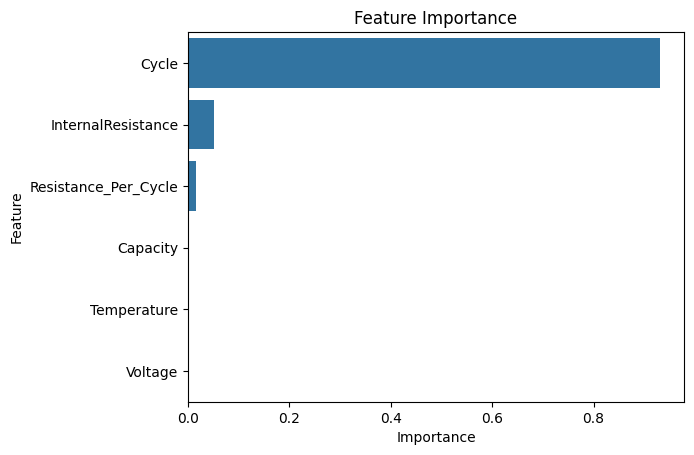

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

ACTUAL VS PREDICTED VALUE

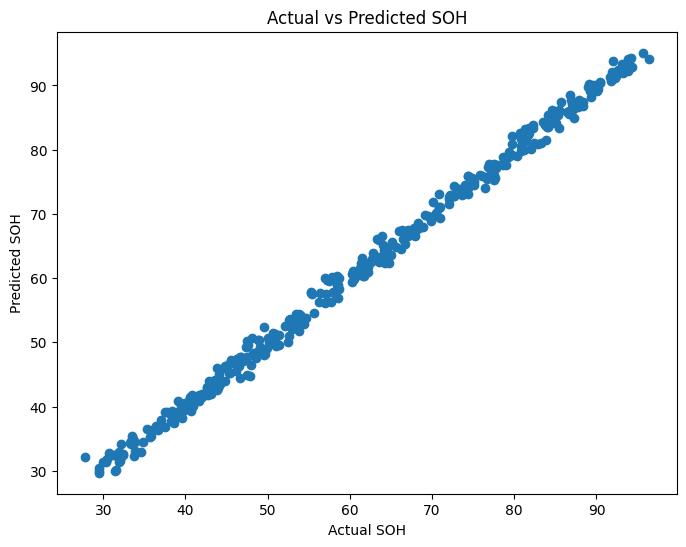

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Actual vs Predicted SOH")

plt.show()

In [43]:
import joblib

joblib.dump(rf, 'soh_prediction_model.pkl')

['soh_prediction_model.pkl']

In [44]:
def predict_soh(
    cycle,
    resistance,
    capacity,
    resistance_per_cycle,
    temperature,
    voltage
):

    data = [[
        cycle,
        resistance,
        capacity,
        resistance_per_cycle,
        temperature,
        voltage
    ]]

    return rf.predict(data)[0]

In [45]:
predict_soh(
    500,
    0.05,
    2.1,
    0.0001,
    30,
    3.8
)

c:\Users\navee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(76.73350560848496)

Health Grade Distribution Analysis

In [46]:
df_clean['Health_Grade'] = pd.cut(
    df_clean['SOH'],
    bins=[0,70,80,90,100],
    labels=['D','C','B','A']
)

print(df_clean['Health_Grade'].value_counts())

Health_Grade
D    1276
C     314
B     277
A     117
Name: count, dtype: int64


Battery Aging Pattern

<Axes: xlabel='Cycle', ylabel='SOH'>

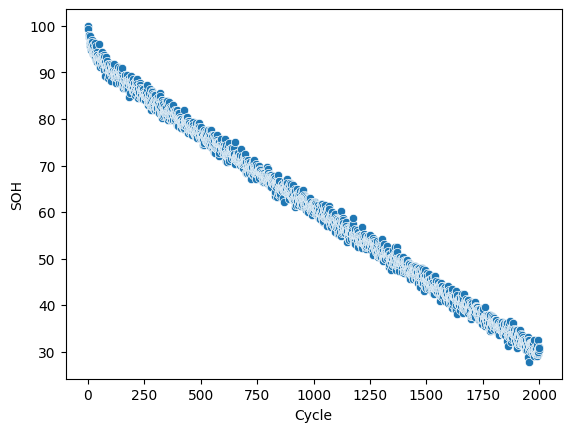

In [47]:
sns.scatterplot(
    x='Cycle',
    y='SOH',
    data=df
)

MAINTANENCE RECOMMENTATION SYSTEM

In [48]:
def recommendation(soh):

    if soh >= 90:
        return "No Maintenance Required"

    elif soh >= 80:
        return "Periodic Monitoring"

    elif soh >= 70:
        return "Maintenance Recommended"

    else:
        return "Battery Replacement Required"

In [49]:
import sys

!{sys.executable} -m pip install geopy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
# Nearest charging station
import pandas as pd
import geocoder
from geopy.distance import geodesic

In [51]:
import geocoder

g = geocoder.ip('me')
user_lat = g.latlng[0]
user_lon = g.latlng[1]

print("Latitude :", user_lat)
print("Longitude:", user_lon)



Latitude : 17.384
Longitude: 78.4564


In [52]:
df_station = pd.read_csv(
    "C:/intern/Indian_EV_Stations_Simplified.csv"
)

print(df_station.head())

                                        Station Name           City   State  \
0                  Tata.ev Luxon Motors - Tata Power     Edappally   Kerala   
1               TML Sree Gokulam Motors - Tata Power      Edappally  Kerala   
2                Tata.ev Gokulam Motors - Tata Power   Choornikkara  Kerala   
3  Taj Cochin Internation Airport Hotel - Tata Power  Nedumbassery   Kerala   
4                      SAJ Earth Resort - Tata Power   Nedumbassery  Kerala   

    Latitude  Longitude    Operator                    Usage Type  \
0  10.011485  76.311387  Tata Power  Public - Membership Required   
1  10.039155  76.315559  Tata Power  Public - Membership Required   
2  10.081303  76.339462  Tata Power  Public - Membership Required   
3  10.159995  76.390154  Tata Power  Public - Membership Required   
4  10.162224  76.384653  Tata Power  Public - Membership Required   

  Connector Type  Power (kW)  
0   CCS (Type 2)        60.0  
1   CCS (Type 2)        30.0  
2   CCS (Type 2) 

In [53]:
# check columns 
print(df_station.columns)

Index(['Station Name', 'City', 'State', 'Latitude', 'Longitude', 'Operator',
       'Usage Type', 'Connector Type', 'Power (kW)'],
      dtype='str')


In [54]:
# Create Vehicle Location

vehicle_location = (
    user_lat,
    user_lon
)

In [55]:
# distance calculation

df_station['Distance_km'] = df_station.apply(
    lambda row: geodesic(
        vehicle_location,
        (
            row['Latitude'],
            row['Longitude']
        )
    ).km,
    axis=1
)

In [56]:
# find nearest charging station

nearest_station = df_station.sort_values(
    by='Distance_km'
).iloc[0]

print(nearest_station)

Station Name      Sri Sai Kanchetty Family Restaurant
City                                        Dichpally
State                                       Telangana
Latitude                                    18.632171
Longitude                                    78.20817
Operator                           Chargezone (India)
Usage Type               Public - Membership Required
Connector Type                           CCS (Type 2)
Power (kW)                                       60.0
Distance_km                                140.626895
Name: 790, dtype: object


In [57]:
# display station information

print("\nNearest Charging Station\n")

print(
    "Station:",
    nearest_station['Station Name']
)

print(
    "Distance:",
    round(
        nearest_station['Distance_km'],
        2
    ),
    "km"
)


Nearest Charging Station

Station: Sri Sai Kanchetty Family Restaurant
Distance: 140.63 km


In [58]:
# predicted soh

predicted_soh = 82.5

# health rate 

if predicted_soh >= 90:
    grade = "A"

elif predicted_soh >= 80:
    grade = "B"

elif predicted_soh >= 70:
    grade = "C"

else:
    grade = "D"

In [59]:
battery_percentage = float(
    input("Enter Current Battery % (0-100): ")
)

if battery_percentage < 0 or battery_percentage > 100:
    print("Invalid Battery Percentage")
else:
    print("Battery Percentage:", battery_percentage)



Battery Percentage: 80.0


In [60]:
# Calculate Remaining Range

battery_capacity = 50

usable_energy = (
    battery_capacity *
    (battery_percentage/100) *
    (predicted_soh/100)
)

efficiency = 6

range_km = (
    usable_energy *
    efficiency
)

In [61]:
# check reachability

station_distance = nearest_station[
    'Distance_km'
]

if range_km > station_distance:

    status = (
        "Reachable"
    )

else:

    status = (
        "Not Reachable"
    )

In [62]:
print(
    "\n===== EV REPORT ====="
)

print(
    "Predicted SOH:",
    round(predicted_soh,2),
    "%"
)

print(
    "Health Grade:",
    grade
)

print(
    "Battery %:",
    battery_percentage
)

print(
    "Estimated Range:",
    round(range_km,2),
    "km"
)

print(
    "Nearest Station:",
    nearest_station[
        'Station Name'
    ]
)

print(
    "Distance:",
    round(
        station_distance,
        2
    ),
    "km"
)

print(
    "Status:",
    status
)


===== EV REPORT =====
Predicted SOH: 82.5 %
Health Grade: B
Battery %: 80.0
Estimated Range: 198.0 km
Nearest Station: Sri Sai Kanchetty Family Restaurant
Distance: 140.63 km
Status: Reachable


In [63]:
import streamlit as st
import pandas as pd
import joblib
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from geopy.distance import geodesic

st.set_page_config(
    page_title="EV Battery Monitoring System",
    layout="wide"
)

# ==========================
# SIDEBAR
# ==========================

menu = st.sidebar.radio(
    "Navigation",
    [
        "Admin Panel",
        "SOH Prediction",
        "Range Calculation",
        "Nearest Charging Station"
    ]
)

# ==========================
# ADMIN PANEL
# ==========================

if menu == "Admin Panel":

    st.title("Admin Panel")

    uploaded_file = st.file_uploader(
        "Upload Battery Dataset",
        type=["csv"]
    )

    if uploaded_file is not None:

        df = pd.read_csv(uploaded_file)

        st.write(df.head())

        if st.button("Train Model"):

            df["Resistance_Per_Cycle"] = (
                df["InternalResistance"]
                /
                (df["Cycle"] + 1)
            )

            features = [
                'Cycle',
                'InternalResistance',
                'Capacity',
                'Resistance_Per_Cycle',
                'Temperature',
                'Voltage'
            ]

            X = df[features]
            y = df['SOH']

            X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                test_size=0.2,
                random_state=42
            )

            model = RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )

            model.fit(
                X_train,
                y_train
            )

            joblib.dump(
                model,
                "soh_model.pkl"
            )

            st.success(
                "Model Trained Successfully"
            )

# ==========================
# SOH PREDICTION
# ==========================

elif menu == "SOH Prediction":

    st.title("SOH Prediction")

    cycle = st.number_input(
        "Cycle Count"
    )

    resistance = st.number_input(
        "Internal Resistance"
    )

    capacity = st.number_input(
        "Capacity"
    )

    temperature = st.number_input(
        "Temperature"
    )

    voltage = st.number_input(
        "Voltage"
    )

    if st.button("Predict SOH"):

        model = joblib.load(
            "soh_model.pkl"
        )

        resistance_per_cycle = (
            resistance /
            (cycle + 1)
        )

        data = [[
            cycle,
            resistance,
            capacity,
            resistance_per_cycle,
            temperature,
            voltage
        ]]

        soh = model.predict(
            data
        )[0]

        if soh >= 90:
            grade = "A"

        elif soh >= 80:
            grade = "B"

        elif soh >= 70:
            grade = "C"

        else:
            grade = "D"

        st.success(
            f"Predicted SOH : {soh:.2f}%"
        )

        st.info(
            f"Battery Grade : {grade}"
        )

# ==========================
# RANGE CALCULATION
# ==========================

elif menu == "Range Calculation":

    st.title(
        "Estimated Range Calculation"
    )

    soh = st.number_input(
        "Predicted SOH (%)"
    )

    battery_percent = st.slider(
        "Battery Percentage",
        0,
        100,
        50
    )

    battery_capacity = st.number_input(
        "Battery Capacity (kWh)",
        value=50
    )

    efficiency = st.number_input(
        "Vehicle Efficiency (km/kWh)",
        value=6
    )

    if st.button("Calculate Range"):

        usable_energy = (
            battery_capacity *
            (battery_percent/100) *
            (soh/100)
        )

        range_km = (
            usable_energy *
            efficiency
        )

        st.success(
            f"Estimated Range : {range_km:.2f} km"
        )

# ==========================
# NEAREST CHARGING STATION
# ==========================

elif menu == "Nearest Charging Station":

    st.title(
        "Nearest Charging Station"
    )

    station_file = st.file_uploader(
        "Upload Charging Station Dataset",
        type=["csv"]
    )

    user_lat = st.number_input(
        "Current Latitude",
        format="%.6f"
    )

    user_lon = st.number_input(
        "Current Longitude",
        format="%.6f"
    )

    if (
        station_file is not None
        and
        st.button(
            "Find Nearest Station"
        )
    ):

        stations = pd.read_csv(
            station_file
        )

        current_location = (
            user_lat,
            user_lon
        )

        stations["Distance_km"] = stations.apply(
            lambda row: geodesic(
                current_location,
                (
                    row["Latitude"],
                    row["Longitude"]
                )
            ).km,
            axis=1
        )

        nearest = stations.sort_values(
            by="Distance_km"
        ).head(5)

        st.subheader(
            "Top 5 Nearest Stations"
        )

        st.dataframe(
            nearest[
                [
                    "Station Name",
                    "City",
                    "Distance_km"
                ]
            ]
        )

2026-06-07 10:06:56.114 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 10:06:56.114 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 10:06:56.114 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 10:06:56.122 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 10:06:56.126 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 10:06:56.129 WARNING streamlit.run